In [1]:
import os
os.chdir("..")

In [2]:
from src.config import *
from src.helpers import raw2df, get_rawdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns

In [3]:
rawdata = get_rawdata()

# EDA
For exploratory analysis, I will primarily use and showcase subject 2's chest data.

In [4]:
s2chest = raw2df(rawdata, 2, 'chest')
s2wrist = raw2df(rawdata, 2, 'wrist')

In [5]:
s2chest.head()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130951,-1.161194,0


Here I showcase the length or recording time for each subject. No subject was recorded for the same amount of time.

In [6]:
totals = []
for subnum in sorted(rawdata.keys()):
    labels = rawdata[subnum]['label'] #get labels
    totals.append({"Subject": subnum, "Total Samples": len(labels),
                    "Duration (sec)": round(len(labels) / 700, 2),
                    "Duration (min)": round(len(labels) / 700 / 60, 2)})
pd.DataFrame(totals)

,Subject,Total Samples,Duration (sec),Duration (min)
0,2,4255300,6079.0,101.32
1,3,4545100,6493.0,108.22
2,4,4496100,6423.0,107.05
3,5,4380600,6258.0,104.30
4,6,4949700,7071.0,117.85
5,7,3666600,5238.0,87.30
6,8,3826200,5466.0,91.10
7,9,3656100,5223.0,87.05
8,10,3847200,5496.0,91.60
9,11,3663100,5233.0,87.22


Here are the sampling rates of each device signal. Not every signal was recorded at the same rate.

In [7]:
pd.DataFrame.from_dict(HZs, orient='index').fillna(0).astype(int).replace(0, '-') #fills missing signals with '-'

,ACC,ECG,EDA,EMG,RESP,TEMP,BVP
chest,700,700,700,700,700,700,-
wrist,32,-,4,-,-,4,64


Here I showcase the time of each label condition for each subject.

In [8]:
totals = []
for subnum in sorted(rawdata.keys()):
    labels = rawdata[subnum]['label'] #get labels
    labels[np.isin(labels, [5,6,7])] = 0 #columns 5,6,7 are to be ignored
    
    # count samples per label
    max_label = max(LABELS.keys())
    counts = np.bincount(labels, minlength=max_label+1)  # counts[0] = Undefined, etc.

    # the row
    row = {"Subject": subnum, "Total Samples (min)": f"{len(labels)/1000:.1f}k ({len(labels)/700/60:.2f} m)"}
    
    # add label counts with minutes in parentheses
    for lab_id, lab_name in LABELS.items():
        row[lab_name] = f"{counts[lab_id]/1000:.1f}k ({counts[lab_id]/700/60:.2f} m)"
    
    totals.append(row)

pd.DataFrame(totals)

,Subject,Total Samples (min),Undefined,Baseline,Stress,Amusement,Meditation
0,2,4255.3k (101.32 m),2233.0k (53.17 m),800.8k (19.07 m),430.5k (10.25 m),253.4k (6.03 m),537.6k (12.80 m)
1,3,4545.1k (108.22 m),2490.6k (59.30 m),798.0k (19.00 m),448.0k (10.67 m),262.5k (6.25 m),546.0k (13.00 m)
2,4,4496.1k (107.05 m),2417.1k (57.55 m),810.6k (19.30 m),444.5k (10.58 m),260.4k (6.20 m),563.5k (13.42 m)
3,5,4380.6k (104.30 m),2272.9k (54.12 m),838.6k (19.97 m),451.5k (10.75 m),261.8k (6.23 m),555.8k (13.23 m)
4,6,4949.7k (117.85 m),2857.4k (68.03 m),826.0k (19.67 m),455.0k (10.83 m),260.4k (6.20 m),550.9k (13.12 m)
5,7,3666.6k (87.30 m),1575.0k (37.50 m),830.2k (19.77 m),448.0k (10.67 m),260.4k (6.20 m),553.0k (13.17 m)
6,8,3826.2k (91.10 m),1722.7k (41.02 m),818.3k (19.48 m),469.0k (11.17 m),259.0k (6.17 m),557.2k (13.27 m)
7,9,3656.1k (87.05 m),1563.1k (37.22 m),826.0k (19.67 m),451.5k (10.75 m),260.4k (6.20 m),555.1k (13.22 m)
8,10,3847.2k (91.60 m),1696.1k (40.38 m),826.0k (19.67 m),507.5k (12.08 m),260.4k (6.20 m),557.2k (13.27 m)
9,11,3663.1k (87.22 m),1549.8k (36.90 m),826.0k (19.67 m),476.0k (11.33 m),257.6k (6.13 m),553.7k (13.18 m)


## Visualizing the data

Here I create some plots to get a visual of the data. I only plot the first minute of each signal. Again, this is only subject 2's data.

In [9]:
# Method for cutting a signal and getting a time vector in seconds
def cut_sig(sigarr, hz, seconds=None):
    if seconds is not None:
        cut_sig = sigarr[:int(hz*seconds)] #cut signal array down to only samples within specified seconds
    else:
        cut_sig = sigarr #or get entire signal array
    time_vec = np.arange(len(cut_sig)) / hz #get time vector in seconds for plotting
    return cut_sig, time_vec

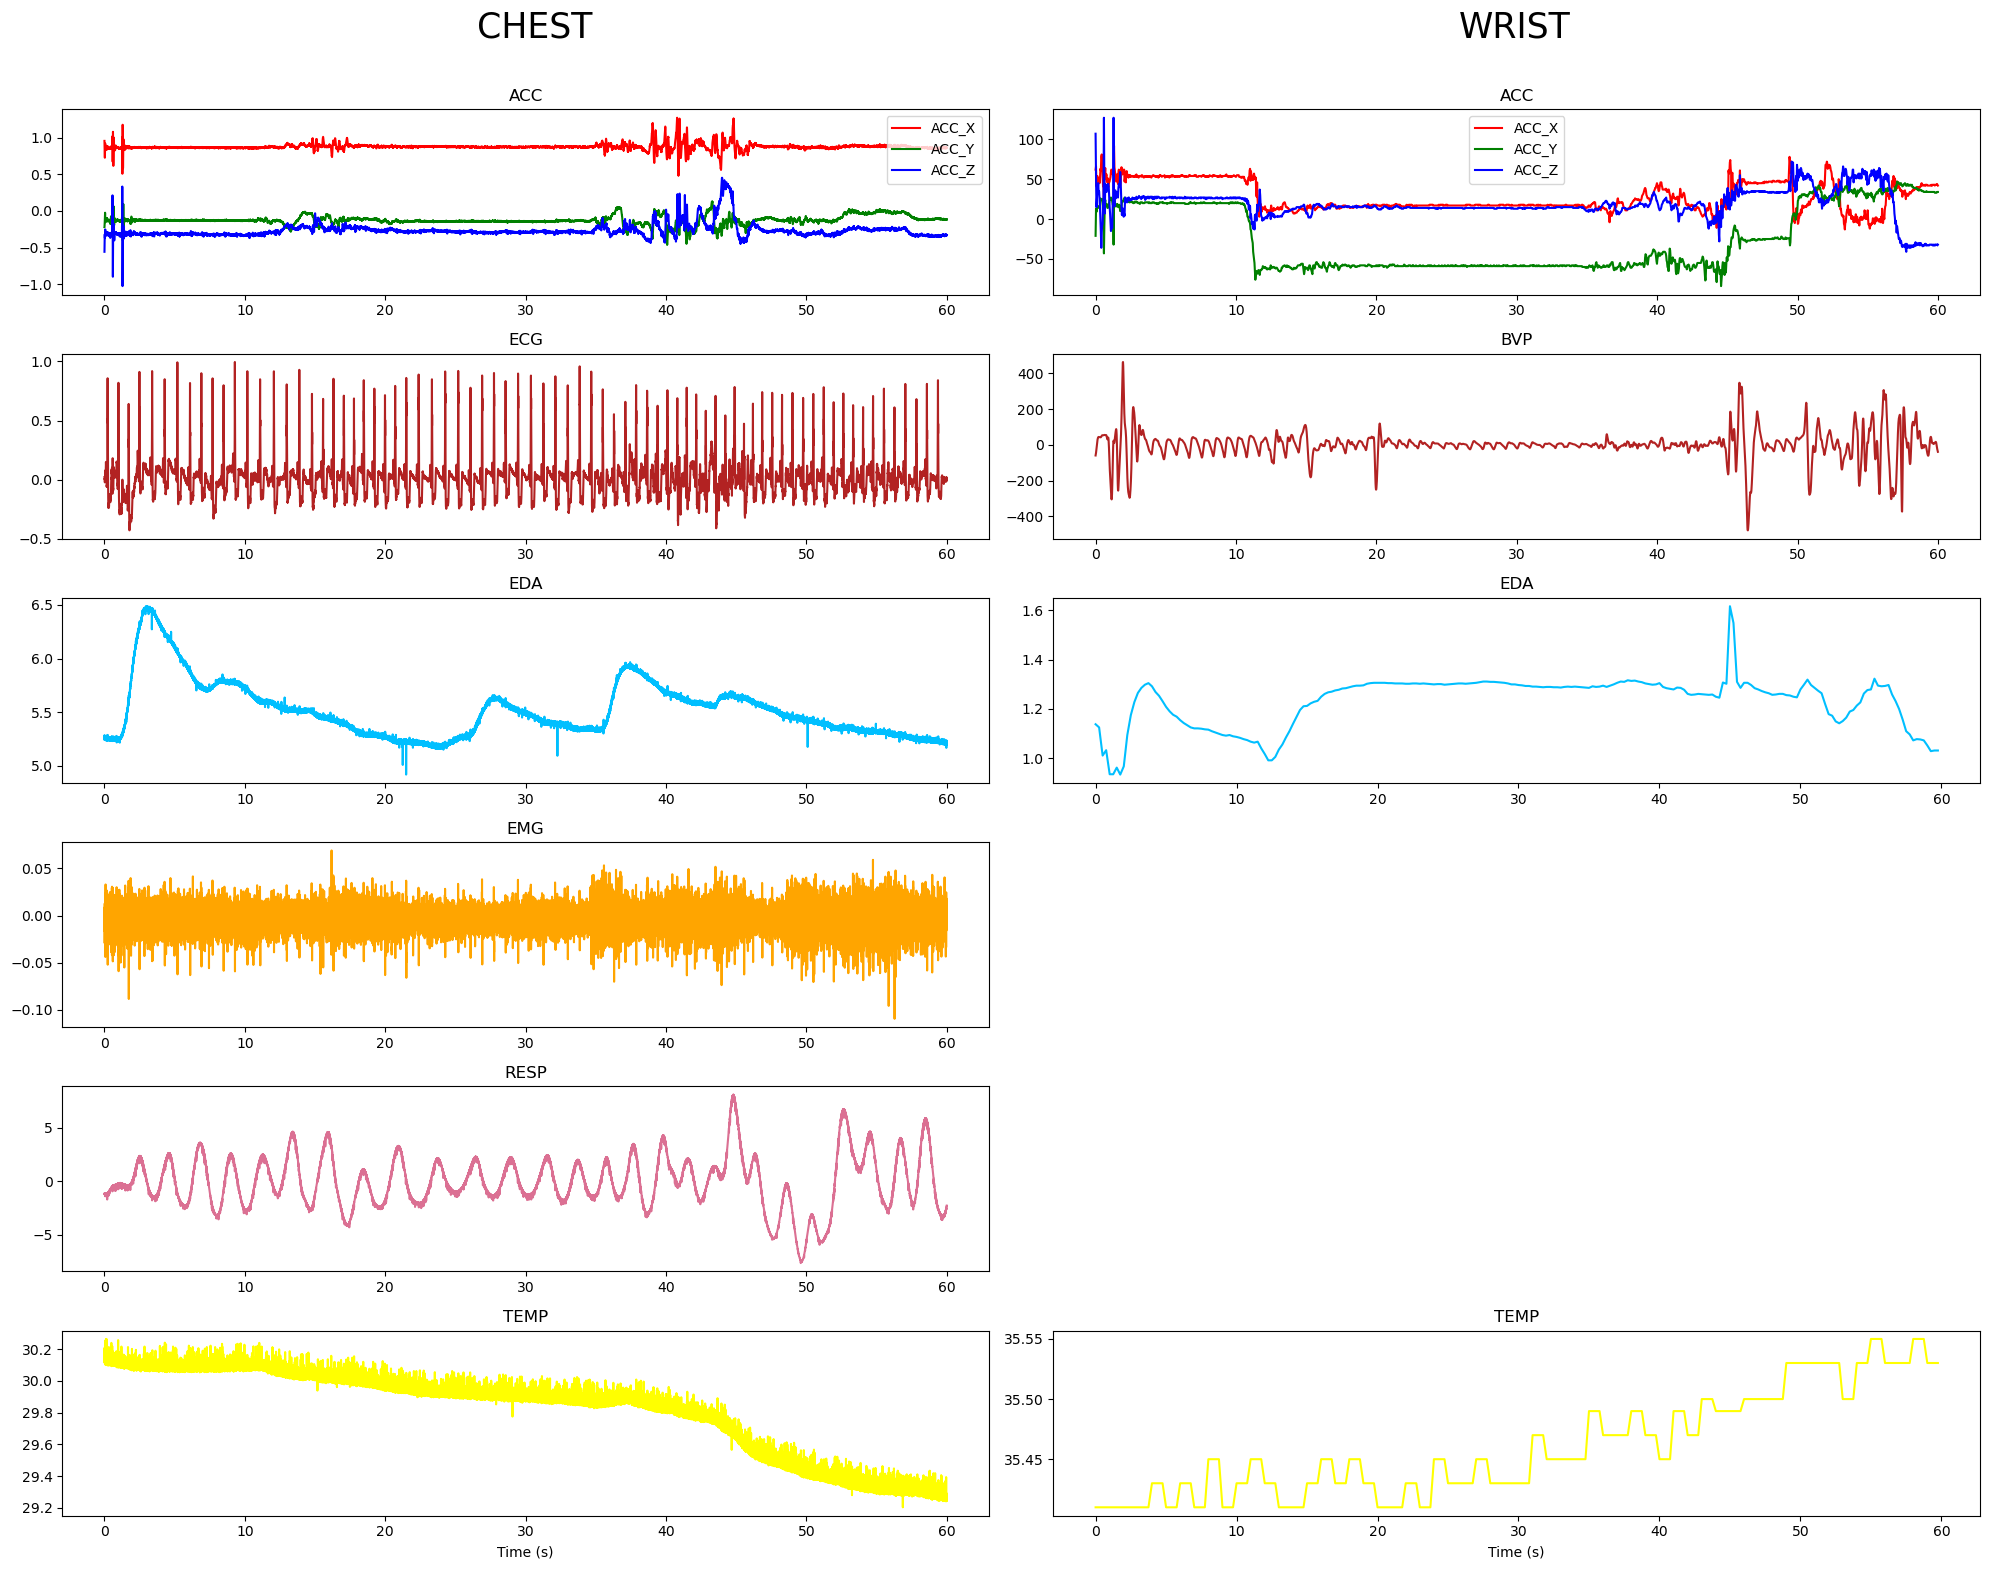

In [10]:
seconds = 60 #want first minute
fig, axes = plt.subplots(6, 2, figsize=(20, 15)) #create 6x2 subplot

# CHEST PLOTS
## ACC
ACC_colors = ['red', 'green', 'blue']
ACC_cols = ['ACC_X', 'ACC_Y', 'ACC_Z']
for i, col in enumerate(ACC_cols):
    sig, t = cut_sig(s2chest[col].values, CHEST_HZ, seconds)
    axes[0, 0].plot(t, sig, color=ACC_colors[i], label=col)
axes[0, 0].set_title('ACC')
axes[0, 0].legend()

## ECG
sig, t = cut_sig(s2chest['ECG'], CHEST_HZ, seconds)
axes[1, 0].plot(t, sig, color='firebrick')
axes[1, 0].set_title('ECG')

## EDA
sig, t = cut_sig(s2chest['EDA'], CHEST_HZ, seconds)
axes[2, 0].plot(t, sig, color='deepskyblue')
axes[2, 0].set_title('EDA')

## EMG
sig, t = cut_sig(s2chest['EMG'], CHEST_HZ, seconds)
axes[3, 0].plot(t, sig, color='orange')
axes[3, 0].set_title('EMG')

## RESP
sig, t = cut_sig(s2chest['Resp'], CHEST_HZ, seconds)
axes[4, 0].plot(t, sig, color='palevioletred')
axes[4, 0].set_title('RESP')

## TEMP
sig, t = cut_sig(s2chest['Temp'], CHEST_HZ, seconds)
axes[5, 0].plot(t, sig, color='yellow')
axes[5, 0].set_title('TEMP')
axes[5, 0].set_xlabel('Time (s)') #label at bottom of column


# WRIST PLOTS
## ACC
for i, col in enumerate(ACC_cols):
    sig, t = cut_sig(s2wrist[col].values, HZs['wrist']['ACC'], seconds)
    axes[0, 1].plot(t, sig, color=ACC_colors[i], label=col)
axes[0, 1].set_title('ACC')
axes[0, 1].legend()

## BVP
sig, t = cut_sig(s2wrist['BVP'], HZs['wrist']['BVP'], seconds)
axes[1, 1].plot(t, sig, color='firebrick')
axes[1, 1].set_title('BVP')

## EDA
sig, t = cut_sig(s2wrist['EDA'], HZs['wrist']['EDA'], seconds)
axes[2, 1].plot(t, sig, color='deepskyblue')
axes[2, 1].set_title('EDA')

## empty, no wrist signal
axes[3, 1].axis('off')

## empty, no wrist signal
axes[4, 1].axis('off')

## TEMP
sig, t = cut_sig(s2wrist['TEMP'], HZs['wrist']['TEMP'], seconds)
axes[5, 1].plot(t, sig, color='yellow')
axes[5, 1].set_title('TEMP')
axes[5, 1].set_xlabel('Time (s)')

# CHEST and WRIST titles on columns 0 and 1
fig.text(0.27, 1.02, 'CHEST', ha='center', va='bottom', fontsize=25)
fig.text(0.76, 1.02, 'WRIST', ha='center', va='bottom', fontsize=25)
plt.tight_layout()
plt.show()

Here I visualize the progression of subject 2's target labels over an entire recording. I've chosen to overly the chest EDA signal as a showcase.

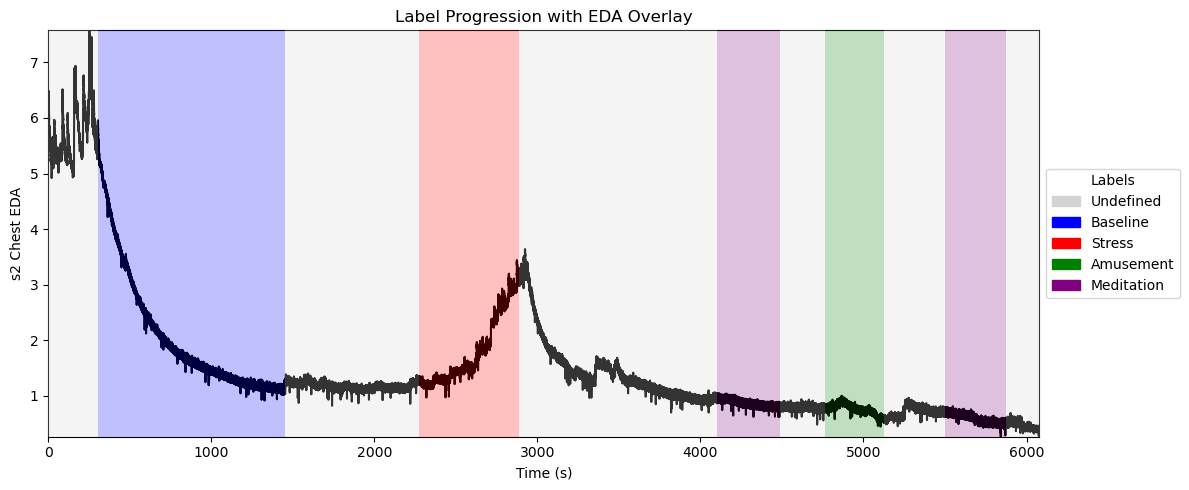

In [11]:
sig = s2chest['EDA'].values
labels = s2chest['label'].values
labels[np.isin(labels, [5, 6, 7])] = 0  #set labels 5,6,7 to 0 so as to be Undefined

sig_cut, t = cut_sig(sig, CHEST_HZ) #get time vector for entire signal

patches = [mpatches.Patch(color=LABEL_CMAP.colors[i], label=LABEL_NAMES[i]) for i in range(len(LABEL_NAMES))]
fig, ax = plt.subplots(figsize=(12, 5))
ymin, ymax = sig_cut.min(), sig_cut.max()

ax.plot(t, sig_cut, color='black')  # signal underneath
ax.imshow([labels], extent=[t.min(), t.max(), ymin, ymax], cmap=LABEL_CMAP, aspect='auto', alpha=0.25, zorder=10)  # labels on top

ax.set_ylabel("s2 Chest EDA")
ax.set_xlabel("Time (s)")
ax.set_title("Label Progression with EDA Overlay")
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5), title='Labels')
plt.tight_layout()
plt.show()

Here I show the counts of each label across all subjects to get an idea of the label distribution.

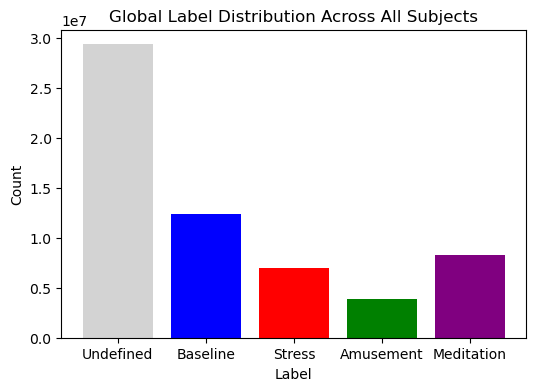

In [13]:
all_labels = []
for subnum in sorted(rawdata.keys()):
    labels = np.array(rawdata[subnum]['label'])
    labels[np.isin(labels, [5,6,7])] = 0
    all_labels.extend(labels)

all_labels = np.array(all_labels)

# count occurrences
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['lightgray','blue','red','green','purple'])
plt.xticks(unique, LABEL_NAMES)
plt.title("Global Label Distribution Across All Subjects")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()